# gmanifold quickstart: sample new continuation states and push them through the model

**What this does.** A fixed prefix is followed by every vocabulary token; the residual state at that last position
is the *real cloud* at each layer (at the embedding it is simply the vocabulary rows). `gmanifold` learns a smooth
parameterisation of the embedding cloud, samples *new* continuation states that are not any vocabulary token, pushes
them through the real model to a chosen layer, and checks them against an independently fitted manifold of the real
states at that layer.

Model: SimpleStories-11M (the SimpleStories collection has 1.25M / 5M / 11M / 30M / 35M checkpoints; no 8M).

In [1]:
import os, subprocess, sys
REPO = os.path.abspath("gmanifold_repo")
if not os.path.exists(REPO):
    token = os.environ.get("GH_TOKEN", "")                                   # only needed while the repository is private
    subprocess.run(["git", "clone", "-q", f"https://{token + '@' if token else ''}github.com/JVrabel/gmanifold.git", REPO], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO], check=True, capture_output=True)
sys.path.insert(0, REPO)
import torch, pandas as pd, gmanifold as gm
from gmanifold import transformer as tr
from transformers import AutoModelForCausalLM, AutoTokenizer
print("gmanifold from", os.path.dirname(gm.__file__))

gmanifold from /workspace/projects/gmanifold_test/gmanifold_repo/gmanifold


## 1. Model, prefix, and the real states at the embedding and at the target layer

In [2]:
MODEL, PREFIX, LAYER, M_LATENT, ALPHA = "SimpleStories/SimpleStories-11M", "Once upon a time, there was a little", "L3.ffn", 16, 0.3
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float32).cuda().eval()
tok = AutoTokenizer.from_pretrained(MODEL)
X_emb, ids = tr.vocab_states(model, tok)                                     # embedding rows of all non-special tokens
keep = ~gm.degenerate_mask(X_emb) & ~gm.outlier_mask(X_emb)                 # drop untrained duplicate rows / isolated rows
X_emb, ids = X_emb[keep], [v for v, k in zip(ids, keep.tolist()) if k]
prefix = tok(PREFIX, add_special_tokens=False)["input_ids"]; L = len(prefix)
seqs = torch.tensor([prefix + [v] for v in ids]); pos = torch.full((len(ids),), L)   # prefix + every token
X_layer = tr.collect_states(model, seqs, pos, [LAYER])[LAYER].cuda()          # real states at LAYER, last position
print(f"{type(model).__name__}, locations {tr.locations(model)}")
print(f"real cloud: {len(ids)} tokens (dropped {int((~keep).sum())}) | embedding {tuple(X_emb.shape)} | {LAYER} {tuple(X_layer.shape)}")
split = torch.randperm(len(ids), generator=torch.Generator().manual_seed(0)); va, trn = split[: len(ids) // 10], split[len(ids) // 10:]

Loading weights:   0%|          | 0/56 [00:00<?, ?it/s]

LlamaForCausalLM, locations ['embed', 'L0.attn', 'L0.ffn', 'L1.attn', 'L1.ffn', 'L2.attn', 'L2.ffn', 'L3.attn', 'L3.ffn', 'L4.attn', 'L4.ffn', 'L5.attn', 'L5.ffn']
real cloud: 3957 tokens (dropped 137) | embedding (3957, 384) | L3.ffn (3957, 384)


## 2. Fit, sample, propagate, validate (one shot)

Two **independent** fits: `M_in` on the embedding rows, `M_out` on the real states at the target layer (it never sees
the samples). Every distance is in units of the local spacing (distance to the 8-th real neighbour). Each table has
the same three reference rows: held-out real states, and real states displaced by 0.5× / 1× their spacing.

In [3]:
M_in  = gm.GlobalManifold(latent_dim=M_LATENT).fit(X_emb[trn],   epochs=300, X_val=X_emb[va],   seed=0)
M_out = gm.GlobalManifold(latent_dim=M_LATENT).fit(X_layer[trn], epochs=300, X_val=X_layer[va], seed=0)
X_sample, info = M_in.sample(2000, alpha=ALPHA, seed=0)                      # new continuation states at the embedding
map_fn = tr.make_map(model, "embed", LAYER, seqs[0], pos=L)                  # the real model, embed -> LAYER, prefix fixed
Y_sample = map_fn(X_sample)                                                  # their images at LAYER
k_in, t_in = gm.KernelScore(X_emb[trn]), gm.TangentCharts(X_emb[trn], M_LATENT)
k_out, t_out = gm.KernelScore(X_layer[trn]), gm.TangentCharts(X_layer[trn], M_LATENT)
print(f"held-out reconstruction / spacing: embedding {M_in.history[-1]['val_recon_over_spacing']:.2f}, {LAYER} {M_out.history[-1]['val_recon_over_spacing']:.2f} | ESS {info['ess']:.0f} of {info['n_candidates']} | coverage of real embeddings {M_in.coverage(X_sample):.2f}")
src = gm.support_report(M_in, X_sample, X_emb[va], k_in, t_in)
dst = gm.support_report(M_out, Y_sample, X_layer[va], k_out, t_out)
dst["images of held-out real"] = gm.support_report(M_out, map_fn(X_emb[va]), kernel=k_out, tangent=t_out)["samples"]
display(pd.DataFrame(src).T.round(3).rename(index={"samples": f"samples α={ALPHA} (embedding)"}))
display(pd.DataFrame(dst).T.round(3).rename(index={"samples": f"images of samples at {LAYER}"}))

held-out reconstruction / spacing: embedding 0.84, L3.ffn 0.72 | ESS 1778 of 16000 | coverage of real embeddings 0.99


,nearest_real,recon,u,tangent
samples α=0.3 (embedding),0.671,0.156,1.182,0.631
held-out real,0.967,0.843,0.997,0.920
real + 0.5x noise,1.101,0.997,0.917,1.045
real + 1x noise,1.392,1.346,0.711,1.341


,nearest_real,recon,u,tangent
images of samples at L3.ffn,0.818,0.688,0.997,0.718
held-out real,0.905,0.723,0.997,0.816
real + 0.5x noise,1.030,0.884,0.906,0.955
real + 1x noise,1.328,1.247,0.673,1.262
images of held-out real,0.905,0.723,0.997,0.816


**How to read it.** `nearest_real`: distance to the closest real state; `recon`: distance to the learned surface;
`u`: kernel score (1 on real states, decays away from the cloud); `tangent`: distance to the nearest local tangent
chart. A sample is on-support when it sits at or inside the *held-out real* row and away from the *noise* rows.
Two things to look for: at the embedding the samples should be closer to real states than held-out real states are
(they interpolate between neighbours), and at the target layer their images should look like the images of real
held-out tokens, not like the noise row.

## 3. Short α sweep: how far from the real states can we go?

In [4]:
rows = {}
for alpha in (0.3, 0.6, 1.0, 1.5):
    x, info = M_in.sample(2000, alpha=alpha, seed=0); y = map_fn(x)
    s = gm.support_report(M_in, x, kernel=k_in, tangent=t_in)["samples"]; d = gm.support_report(M_out, y, kernel=k_out, tangent=t_out)["samples"]
    rows[f"α={alpha}"] = {"emb: nearest": s["nearest_real"], "emb: u": s["u"], "emb: tangent": s["tangent"], "emb: coverage": M_in.coverage(x), "ESS": info["ess"],
                          f"{LAYER}: nearest": d["nearest_real"], f"{LAYER}: u": d["u"], f"{LAYER}: tangent": d["tangent"]}
for name in ("held-out real", "real + 0.5x noise", "real + 1x noise"):
    rows[f"band: {name}"] = {"emb: nearest": src[name]["nearest_real"], "emb: u": src[name]["u"], "emb: tangent": src[name]["tangent"],
                             f"{LAYER}: nearest": dst[name]["nearest_real"], f"{LAYER}: u": dst[name]["u"], f"{LAYER}: tangent": dst[name]["tangent"]}
display(pd.DataFrame(rows).T.round(3))

,emb: nearest,emb: u,emb: tangent,emb: coverage,ESS,L3.ffn: nearest,L3.ffn: u,L3.ffn: tangent
α=0.3,0.671,1.182,0.631,0.987,1778.474,0.818,0.997,0.718
α=0.6,0.725,1.144,0.673,0.967,1863.697,0.825,1.003,0.727
α=1.0,0.870,1.036,0.792,0.954,1685.135,0.885,1.012,0.784
α=1.5,1.133,0.803,1.019,0.168,1166.155,0.960,1.026,0.869
band: held-out real,0.967,0.997,0.920,NaN,NaN,0.905,0.997,0.816
band: real + 0.5x noise,1.101,0.917,1.045,NaN,NaN,1.030,0.906,0.955
band: real + 1x noise,1.392,0.711,1.341,NaN,NaN,1.328,0.673,1.262


**Reading the sweep.** α is the sampling radius in units of one typical inter-point distance of the real cloud.
At the embedding: α = 0.3 and 0.6 sit above the held-out-real row on `u` and inside it on the distances, with coverage
≈ 1; α = 1.0 is marginal (u near the real row, still above the 0.5× noise row); α = 1.5 falls to the 1× noise row and
coverage collapses. At the target layer the images of *all* α look like real images: the network pulls mildly
off-support inputs back onto its manifold within a few blocks (real states displaced by one spacing are healed the
same way), so the destination check alone cannot tell a good α from a bad one; the embedding-side check is the one
that discriminates. Use α = 0.3 for anything that must be trusted, up to 0.6 to deliberately move away from the
observed states.

## 4. Pictures: real states and samples, at the embedding and at the target layer

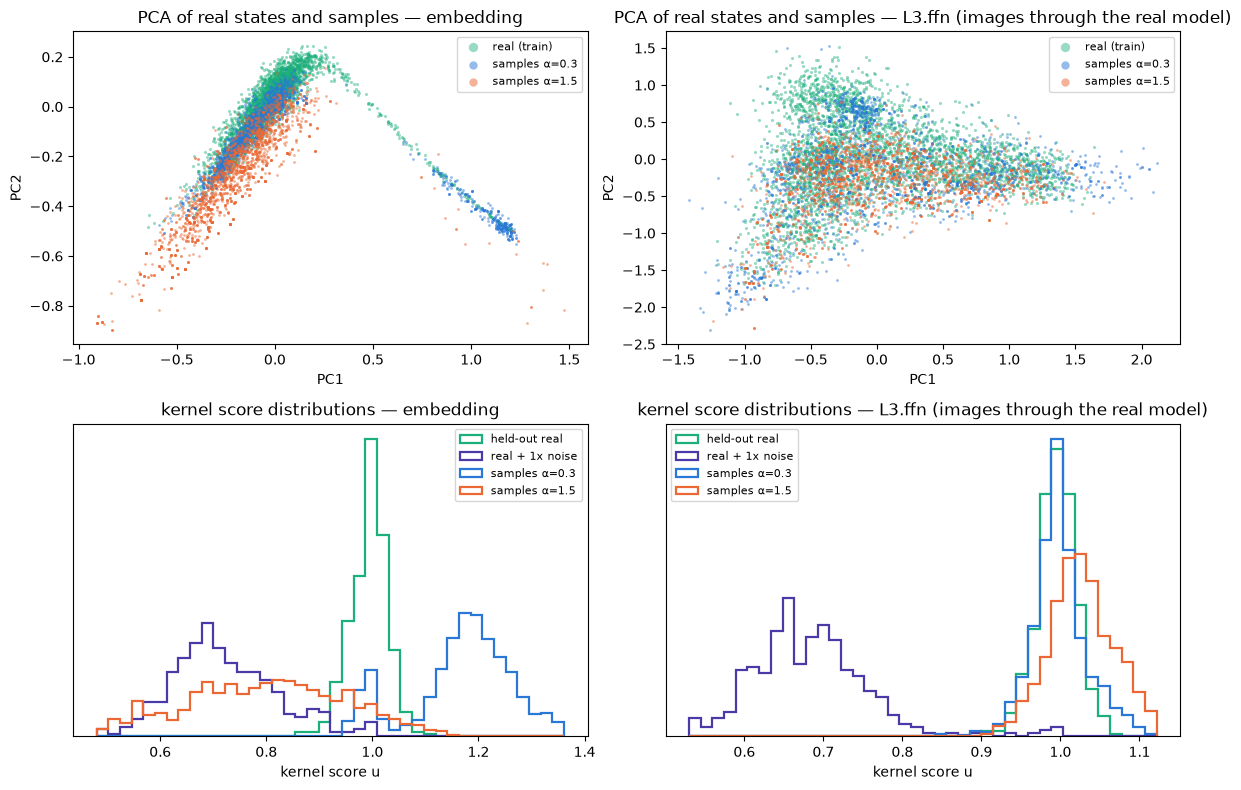

In [5]:
import matplotlib.pyplot as plt
x03, x15 = M_in.sample(2000, alpha=0.3, seed=0)[0], M_in.sample(2000, alpha=1.5, seed=0)[0]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for k, (ref, sets, title) in enumerate(((X_emb[trn], {"samples α=0.3": x03, "samples α=1.5": x15}, "embedding"),
                                         (X_layer[trn], {"samples α=0.3": map_fn(x03), "samples α=1.5": map_fn(x15)}, f"{LAYER} (images through the real model)"))):
    mu = ref.mean(0); W = torch.linalg.svd(ref - mu, full_matrices=False)[2][:2].T; P = lambda Z: ((Z - mu) @ W).cpu()
    p = P(ref); ax[0, k].scatter(p[:, 0], p[:, 1], s=5, c="#1baf7a", alpha=0.45, lw=0, label="real (train)")
    for (lab, Z), col in zip(sets.items(), ("#2a78d6", "#eb6834")):
        p = P(Z); ax[0, k].scatter(p[:, 0], p[:, 1], s=4, c=col, alpha=0.5, lw=0, label=lab)
    ax[0, k].set_title(f"PCA of real states and samples — {title}"); ax[0, k].legend(fontsize=8, markerscale=3); ax[0, k].set_xlabel("PC1"); ax[0, k].set_ylabel("PC2")
    kern, Xva_, M_ = (k_in, X_emb[va], M_in) if k == 0 else (k_out, X_layer[va], M_out)
    j = gm.knn(M_.X, 1, Xva_)[1][:, 0]; g = torch.Generator(device="cuda").manual_seed(0)
    nz = torch.randn(Xva_.shape, device="cuda", generator=g); noise = Xva_ + nz / nz.norm(dim=1, keepdim=True) * M_.unit(j)[:, None]
    series = {"held-out real": (kern(Xva_), "#1baf7a"), "real + 1x noise": (kern(noise), "#4a3aa7"), "samples α=0.3": (kern(sets["samples α=0.3"]), "#2a78d6"), "samples α=1.5": (kern(sets["samples α=1.5"]), "#eb6834")}
    lo, hi = min(float(v.quantile(0.01)) for v, _ in series.values()), max(float(v.quantile(0.99)) for v, _ in series.values())
    for lab, (v, col) in series.items():
        ax[1, k].hist(v.cpu().numpy(), bins=40, range=(lo, hi), density=True, histtype="step", lw=1.6, color=col, label=lab)
    ax[1, k].set_xlabel("kernel score u"); ax[1, k].set_yticks([]); ax[1, k].set_title(f"kernel score distributions — {title}"); ax[1, k].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Reading the pictures.** Top: the α = 0.3 samples (blue) trace the real cloud (grey) at both the embedding and
the target layer; the α = 1.5 samples (orange) spill outside it at the embedding but are pulled back into the cloud by
the network. Bottom: the kernel-score histograms show the same thing quantitatively — at the embedding the α = 0.3
samples sit at or above the held-out-real distribution while α = 1.5 overlaps the noise; at the target layer both
overlap the real distribution.